# Utils

This notebook is only used to try out different things without changing the other notebooks too much.

In [1]:
import os
import shutil
import h5py
import numpy as np
import sys
import pandas as pd
import json
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.append("..")
sys.path.append("../code")

from dataset import PointCloudEmbeddingSequenceDataset
from models.DeepCAD.cadlib.visualize import vec2CADsolid
from OCC.Core.BRepCheck import BRepCheck_Analyzer
from OCC.Extend.DataExchange import write_step_file
from OCC.Core.STEPControl import STEPControl_Reader
from OCC.Core.StlAPI import StlAPI_Writer
from OCC.Core.BRepMesh import BRepMesh_IncrementalMesh
from models.DeepCAD.cadlib.extrude import CADSequence
from models.DeepCAD.cadlib.visualize import create_CAD

In [15]:
def copy_to_temp(dataset, idx):
    cad_seq_path = dataset.get_cad_seq_path(idx)
    pc_path = dataset.get_pc_path(idx)
    print(idx)
    print(pc_path)
    json_path = pc_path.replace("pc_cad", "cad_json")
    json_path = json_path.replace("ply", "json")
    print(pc_path, json_path)
    
    temp_dir = "../data/temporary"
    #if os.path.exists(temp_dir):
     #   shutil.rmtree(temp_dir)
    os.makedirs(temp_dir, exist_ok=True)

    dest_path_cad_seq = os.path.join(temp_dir, os.path.basename(cad_seq_path))
    dest_path_pc = os.path.join(temp_dir, os.path.basename(pc_path))
    dest_path_json = os.path.join(temp_dir, os.path.basename(json_path))

    shutil.copy(cad_seq_path, dest_path_cad_seq)
    shutil.copy(pc_path, dest_path_pc)
    shutil.copy(json_path, dest_path_json)
    
    print(f"Copied {cad_seq_path} to {dest_path_cad_seq}")
    print(f"Copied {pc_path} to {dest_path_pc}")
    print(f"Copied {json_path} to {dest_path_json}")
    return dest_path_json

def change_keys(h5_file):
    """Changes the keys from 'vec' to 'out_vec' in order to be able to show the sample using show.py"""
    with h5py.File(h5_file, 'r+') as hf:

        if 'vec' in hf:
            data = hf['vec'][:]
            hf.create_dataset('out_vec', data=data)
            del hf['vec']
            print(f"Changed keys from 'vec' to 'out_vec' in {h5_file}")

def export2step(json_path):
    filter = True
    save_path = os.path.join(*json_path.split("/")[:-1], os.path.splitext(os.path.basename(json_path))[0] + '.step')

    with open(json_path, "r") as fp:
        data = json.load(fp)

    cad_seq = CADSequence.from_dict(data)
    cad_seq.normalize()
    shape = create_CAD(cad_seq)

    write_step_file(shape, save_path)
    return save_path

def step2stl(step_path):

    save_path = os.path.join(*step_path.split("/")[:-1], os.path.splitext(os.path.basename(step_path))[0] + '.stl')
    step_reader = STEPControl_Reader()
    step_reader.ReadFile(step_path)
    step_reader.TransferRoots()
    shape = step_reader.OneShape()

    BRepMesh_IncrementalMesh(shape, 0.1)

    stl_writer = StlAPI_Writer()
    stl_writer.Write(shape, save_path)
    print(f"Wrote stl file to {save_path}")

def visualize_gt(dataset, idx):
    dest_path_h5 = copy_to_temp(dataset, idx)
   # change_keys(dest_path_h5)
    step_path = export2step(dest_path_h5)
    step2stl(step_path)

In [3]:
def find_index(file_id, ds):
    """To find specific files.
    If provided with a file id (str, no extension), returns the index in the dataset.
    """
    pcs = ds.pc
    
    for i, data in enumerate(pcs):
        id = os.path.splitext(os.path.basename(data))[0]
        if id == file_id:
            print(i)
            return i
            break

In [4]:
dataset = PointCloudEmbeddingSequenceDataset("../data", 'train', use_normals=False, verbose=True)
dataset_val = PointCloudEmbeddingSequenceDataset("../data", 'validation', use_normals=False, verbose=True)
dataset_test = PointCloudEmbeddingSequenceDataset("../data", 'test', use_normals=False, verbose=True)

Loading train dataset 

Number of samples that should be in the train set: 161240
Files on disk: 160982 --> There are 258 missing point cloud files in the train set.

Checking latent representation:
All latent represenations are valid.

--- DONE ---

Loading validation dataset 

Number of samples that should be in the validation set: 8946
Files on disk: 8928 --> There are 18 missing point cloud files in the validation set.

Checking latent representation:
All latent represenations are valid.

--- DONE ---

Loading test dataset 

Number of samples that should be in the test set: 8052
Files on disk: 8038 --> There are 14 missing point cloud files in the test set.

Checking latent representation:
All latent represenations are valid.

--- DONE ---



In [23]:
index = find_index('00803465', dataset)

In [38]:
a = dataset_test[58]
a['pc'].shape

torch.Size([2048, 3])

In [21]:
from models.DeepCAD.cadlib.visualize import vec2CADsolid
from OCC.Core.Bnd import Bnd_Box
from OCC.Core.BRepBndLib import brepbndlib_Add
from OCC.Extend.DataExchange import write_stl_file

index = 4122
a = dataset_test[index]

stl_path = "examples/dc_{}.stl".format(index)
shape = vec2CADsolid(a['tgt_vec'].numpy())
bbox = Bnd_Box()
brepbndlib_Add(shape, bbox)
write_stl_file(shape, stl_path, linear_deflection=0.05, angular_deflection=0.05)
print(f"Saved stl file to {stl_path}")

Saved stl file to examples/dc_4122.stl


In [39]:
shape = a['tgt_vec']

In [18]:
visualize_gt(dataset_test, 4566)

4566
../data/pc_cad/0076/00766680.ply
../data/pc_cad/0076/00766680.ply ../data/cad_json/0076/00766680.json
Copied ../data/cad_vec/0076/00766680.h5 to ../data/temporary/00766680.h5
Copied ../data/pc_cad/0076/00766680.ply to ../data/temporary/00766680.ply
Copied ../data/cad_json/0076/00766680.json to ../data/temporary/00766680.json

*******************************************************************
******        Statistics on Transfer (Write)                 ******
Wrote stl file to ../data/temporary/00766680.stl

*******************************************************************
******        Transfer Mode = 0  I.E.  As Is       ******
******        Transferring Shape, ShapeType = 2                      ******
** WorkSession : Sending all data
 Step File Name : ../data/temporary/00766680.step(536 ents)  Write  Done


## create own data

The non-translated value of 95 is always set to sketch size.
Abfolge: (theta, phi, gamma) in args


1. Rotate y by theta
2. Rotate new z by phi
3. Rotate new y by gamma

Use right hand rule! (Thumb - x, index - y, middle - z)

In [51]:
for lol in shape:
    for lol2 in lol:
            print(lol2.item(), end=' ')
    print()
beveled_cylinder = shape[6:]
beveled_cylinder[1, -2] = 0 # join to new-body

4 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
0 223 128 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
0 223 200 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
0 128 200 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
0 128 128 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
5 -1 -1 -1 -1 -1 128 128 128 46 66 128 164 161 128 0 0 
4 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
2 176 128 -1 -1 48 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
5 -1 -1 -1 -1 -1 128 128 128 92 128 161 72 194 128 0 0 
4 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
0 223 86 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
0 223 128 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
0 128 128 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
5 -1 -1 -1 -1 -1 192 64 192 86 128 227 90 210 128 2 1 
3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
3 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 
3 

In [52]:
beveled_cylinder[:8]

tensor([[  4,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1],
        [  2, 176, 128,  -1,  -1,  48,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,   0,  -1],
        [  5,  -1,  -1,  -1,  -1,  -1, 128, 128, 128,  92, 128, 161,  72, 194,
         128,   0,   0],
        [  4,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1],
        [  0, 223,  86,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1],
        [  0, 223, 128,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1],
        [  0, 128, 128,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1],
        [  5,  -1,  -1,  -1,  -1,  -1, 192,  64, 192,  86, 128, 227,  90, 210,
         128,   2,   1]])

In [53]:
beveled_cylinder_np = beveled_cylinder.numpy()

In [54]:
from models.DeepCAD.cadlib.visualize import vec2CADsolid
from OCC.Core.Bnd import Bnd_Box
from OCC.Core.BRepBndLib import brepbndlib_Add
from OCC.Extend.DataExchange import write_stl_file

stl_path = "examples/beveled_cylinder.stl"
shape = vec2CADsolid(beveled_cylinder_np)
bbox = Bnd_Box()
brepbndlib_Add(shape, bbox)
write_stl_file(shape, stl_path, linear_deflection=0.05, angular_deflection=0.05)
print(f"Saved stl file to {stl_path}")

Saved stl file to examples/beveled_cylinder.stl


In [13]:
# Circle example
seq = [
    [4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 223, 128, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 223, 223, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 128, 223, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 128, 128, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [5, -1, -1, -1, -1, -1, 128, 128, 128, 128, 128, 0, 128, 256, 128, 0, 0],
    [4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [2, 128, 128, -1, -1, 95, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [5, -1, -1, -1, -1, -1, 128, 128, 128, 192, 192, 128, 64, 192, 128, 0, 0]
]

In [9]:
seq = [
    [4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 223, 128, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 223, 223, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 128, 223, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 128, 128, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [5, -1, -1, -1, -1, -1, 128, 128, 128, 128, 128, 0, 128, 256, 128, 0, 0],
    [4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 223, 128, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1], #223
    [1, 223, 223, 128, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 128, 223, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 128, 128, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [5, -1, -1, -1, -1, -1, 128, 128, 128, 128, 128, 128, 128, 192, 128, 0, 0],
    [4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 223, 128, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 223, 223, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 128, 223, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [0, 128, 128, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
    [5, -1, -1, -1, -1, -1, 192, 160, 192, 0, 128, 0, 128, 256, 128, 1, 0]
]

In [18]:
# example train set index 13 to figure out error:
# RuntimeError: Standard_ConstructionErrorBRepSweep_Translation::
# Constructor raised from method BRepPrimAPI_MakePrism of class BRepPrimAPI_MakePrism
seq = [
    [4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [0, 223, 128, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [0, 223, 191, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [0, 176, 223, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [0, 128, 191, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [0, 128, 128, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [0, 206, 129, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [0, 206, 192, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [0, 145, 192, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [0, 145, 129, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [5, -1, -1, -1, -1, -1, 192, 64, 192, 113, 128, 116, 68, 224, 128, 0, 0, ]
]

In [38]:
seq = [
    [4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [0, 223, 128, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [0, 223, 181, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [0, 128, 181, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [0, 128, 128, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, ],
    [5, -1, -1, -1, -1, -1, 192, 64, 192, 125, 128, 117, 45, 127, 128, 1, 0, ],
]

In [39]:
eos_row = [3, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]

seq_np = np.array(seq, dtype=np.float32)
num_pad_rows = 60 - seq_np.shape[0]
pad_array = np.tile(eos_row, (num_pad_rows, 1))
seq_np_pad = np.concatenate([seq_np, pad_array], axis=0)  
seq_len = seq_np_pad[:,0].tolist().index(3)
cad_seq = CADSequence.from_vector(seq_np_pad, is_numerical=True)
#print(cad_seq.seq[2].profile.start_point)
#print(cad_seq.seq[2].profile.bbox)
#print(cad_seq.seq[2].profile.bbox_size)
# cad_seq.seq[2].profile.to_image()
#print(bbox_size)
#sketch_size = cad_seq.seq[0].sketch_size
#cad_seq.seq[0].profile.denormalize(sketch_size)
#cad_seq.seq[0].profile.to_image()

In [40]:
#
#print(cad_seq.seq[0].profile.bbox_size)

print(cad_seq, end='\n\n')
custom_shape = create_CAD(cad_seq)
print(cad_seq)
write_step_file(custom_shape, "examples/test.step")
step2stl("examples/test.step")

(0)Sketch-Extrude pair:
  -origin: [-0.0234  0.     -0.0859], normal: [ 0. -1.  0.], x_axis: [ 1.  0. -0.], y_axis: [0. 0. 1.]
  -sketch position: [-0.0234  0.     -0.0859], sketch size: 0.3516
  -operation:1, type:0, extent_one:-0.0078125, extent_two:0.0
  -Profile:Loop:
      -Line: start([128. 128.]), end([223. 128.])
      -Line: start([223. 128.]), end([223. 181.])
      -Line: start([223. 181.]), end([128. 181.])
      -Line: start([128. 181.]), end([128. 128.])

(0)Sketch-Extrude pair:
  -origin: [-0.0234  0.     -0.0859], normal: [ 0. -1.  0.], x_axis: [ 1.  0. -0.], y_axis: [0. 0. 1.]
  -sketch position: [-0.0234  0.     -0.0859], sketch size: 0.3516
  -operation:1, type:0, extent_one:-0.0078125, extent_two:0.0
  -Profile:Loop:
      -Line: start([0. 0.]), end([0.3515625 0.       ])
      -Line: start([0.3515625 0.       ]), end([0.3515625  0.19613487])
      -Line: start([0.3515625  0.19613487]), end([0.         0.19613487])
      -Line: start([0.         0.19613487]), end([0

In [8]:
for e in cad_seq.seq:
    print(e)

Sketch-Extrude pair:
  -origin: [ 0.  0. -1.], normal: [0. 0. 1.], x_axis: [1. 0. 0.], y_axis: [0. 1. 0.]
  -sketch position: [ 0.  0. -1.], sketch size: 1.0
  -operation:0, type:0, extent_one:1.0, extent_two:0.0
  -Profile:Loop:
      -Line: start([0. 0.]), end([1. 0.])
      -Line: start([1. 0.]), end([1. 1.])
      -Line: start([1. 1.]), end([0. 1.])
      -Line: start([0. 1.]), end([0. 0.])
Sketch-Extrude pair:
  -origin: [0. 0. 0.], normal: [0. 0. 1.], x_axis: [1. 0. 0.], y_axis: [0. 1. 0.]
  -sketch position: [0. 0. 0.], sketch size: 1.0
  -operation:0, type:0, extent_one:0.5, extent_two:0.0
  -Profile:Loop:
      -Line: start([0. 0.]), end([1. 0.])
      -Arc: start([1. 0.]), end([1. 1.]), mid([0.5 0.5])
      -Line: start([1. 1.]), end([0. 1.])
      -Line: start([0. 1.]), end([0. 0.])
Sketch-Extrude pair:
  -origin: [-1.  0. -1.], normal: [0.7071 0.7071 0.    ], x_axis: [-0.7071  0.7071 -0.    ], y_axis: [-0.  0.  1.]
  -sketch position: [-1.  0. -1.], sketch size: 1.0
  -oper

In [17]:
for a in cad_seq.seq:
    print(a.sketch_size)
    print(a.profile.bbox_size)
    for b in a.profile.children:
        print(b)

0.09375
0.06710526315789474
Loop:
      -Line: start([0. 0.]), end([0.06710526 0.        ])
      -Line: start([0.06710526 0.        ]), end([0.06710526 0.06710526])
      -Line: start([0.06710526 0.06710526]), end([0.         0.06710526])
      -Line: start([0.         0.06710526]), end([0. 0.])


In [36]:
lol = np.array([5, -1, -1, -1, -1, -1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

In [37]:
N_ARGS_SKETCH = 5 # sketch parameters: x, y, alpha, f, r
N_ARGS_PLANE = 3 # sketch plane orientation: theta, phi, gamma
N_ARGS_TRANS = 4 # sketch plane origin + sketch bbox size: p_x, p_y, p_z, s
N_ARGS_EXT_PARAM = 4 # extrusion parameters: e1, e2, b, u
N_ARGS_EXT = N_ARGS_PLANE + N_ARGS_TRANS + N_ARGS_EXT_PARAM
N_ARGS = N_ARGS_SKETCH + N_ARGS_EXT

In [38]:
ext_vec = lol[-N_ARGS_EXT:]
ext_vec

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [39]:
sket_pos = ext_vec[N_ARGS_PLANE:N_ARGS_PLANE + 3]
sket_pos

array([4, 5, 6])

In [40]:
sket_size = ext_vec[N_ARGS_PLANE + N_ARGS_TRANS - 1]
sket_size

7

In [41]:
ext_vec[:N_ARGS_PLANE]

array([1, 2, 3])

In [67]:
import torch

In [4]:
lol = torch.load("../models/trained_models/github_model_pn/latest.pth", weights_only = True, map_location=torch.device('cpu'))

In [5]:
print(type(lol))
print(lol.keys())
for i, a in enumerate(lol['model_state_dict'].keys()):
    print(i, a.ljust(50), lol['model_state_dict'][a].shape)
print(lol['model_state_dict']['SA_modules.0.mlps.0.0.weight'])

<class 'dict'>
dict_keys(['clock', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict'])
0 SA_modules.0.mlps.0.0.weight                       torch.Size([32, 6, 1, 1])
1 SA_modules.0.mlps.0.1.weight                       torch.Size([32])
2 SA_modules.0.mlps.0.1.bias                         torch.Size([32])
3 SA_modules.0.mlps.0.1.running_mean                 torch.Size([32])
4 SA_modules.0.mlps.0.1.running_var                  torch.Size([32])
5 SA_modules.0.mlps.0.1.num_batches_tracked          torch.Size([])
6 SA_modules.0.mlps.0.3.weight                       torch.Size([32, 32, 1, 1])
7 SA_modules.0.mlps.0.4.weight                       torch.Size([32])
8 SA_modules.0.mlps.0.4.bias                         torch.Size([32])
9 SA_modules.0.mlps.0.4.running_mean                 torch.Size([32])
10 SA_modules.0.mlps.0.4.running_var                  torch.Size([32])
11 SA_modules.0.mlps.0.4.num_batches_tracked          torch.Size([])
12 SA_modules.0.mlps.0.6.weight        

In [27]:
lol['model_state_dict']["SA_modules.0.mlps.0.0.weight"] = lol['model_state_dict']["SA_modules.0.mlps.0.0.weight"][:, :3, :, :]

In [28]:
torch.save(lol, "../data/latent/pretrained/test_pretrained_pn2/pc2cad/model/latest_mod.pth")

In [31]:
lol = torch.load("../data/latent/pretrained/test_pretrained_pn2/pc2cad/model/latest_mod.pth", weights_only = True, map_location=torch.device('cpu'))

In [59]:
#print(type(lol))
#print(lol.keys())
#for i, a in enumerate(lol['model_state_dict'].keys()):
#    print(i, a.ljust(50), lol['model_state_dict'][a].shape)
#print(lol['model_state_dict']['SA_modules.0.mlps.0.0.weight'])

In [33]:
lol = torch.load("../models/trained_models/fifth_official_run/best.pth", weights_only = True, map_location=torch.device('cpu'))

In [58]:
#print(type(lol))
#print(lol.keys())
#for i, a in enumerate(lol['model_state_dict'].keys()):
 #   print(i, a.ljust(50), lol['model_state_dict'][a].shape)

## Check Null triangulation

The data needs to be checked! When sampling pc from cad models there is the warning "skipped x faces due to null triangulation", which leads to point clouds not alligning to the CAD models!

In [4]:
import sys
import os
import random
import torch
import importlib
import csv
import numpy as np
sys.path.append(os.path.join('..', 'models','Pointnet_Pointnet2_pytorch', 'models'))
sys.path.append("..")
sys.path.append("../code")

from models.DeepCAD.config.configAE import ConfigAE
from models.DeepCAD.trainer.trainerAE import TrainerAE
from dataset import PointCloudEmbeddingSequenceDataset, PointCloudEmbeddingDataset
from models.DeepCAD.cadlib.macro import ALL_COMMANDS, CMD_ARGS_MASK, EOS_IDX, SOL_IDX, EXT_IDX, ARC_IDX
from models.DeepCAD.cadlib.visualize import vec2CADsolid, CADsolid2pc
from models.DeepCAD.utils import read_ply
from scipy.spatial import cKDTree as KDTree
import pandas as pd



In [5]:
def chamfer_dist(gt_points, gen_points, offset=0, scale=1):
    gen_points = gen_points / scale - offset

    # one direction
    gen_points_kd_tree = KDTree(gen_points)
    one_distances, one_vertex_ids = gen_points_kd_tree.query(gt_points)
    gt_to_gen_chamfer = np.mean(np.square(one_distances))

    # other direction
    gt_points_kd_tree = KDTree(gt_points)
    two_distances, two_vertex_ids = gt_points_kd_tree.query(gen_points)
    gen_to_gt_chamfer = np.mean(np.square(two_distances))

    return gt_to_gen_chamfer + gen_to_gt_chamfer

In [6]:
def normalize_pc(points):
    scale = np.max(np.abs(points))
    points = points / scale
    return points

In [7]:
def calculate_CD(vec_pred, gt_pc_path, vec_target, data_id):

    seq_len = vec_target[:,0].tolist().index(EOS_IDX)
    vec_pred = vec_pred.squeeze()[:seq_len]

    try:
        shape = vec2CADsolid(vec_pred) # out vec only contains until target seq length
    except Exception as e:
        return float('nan') # Create CAD failed
    
    try:
        out_pc = CADsolid2pc(shape, 2000, data_id) # 2000 is the number of sampled points
    except Exception as e:
        return float('nan') # Create PC failed

    if np.max(np.abs(out_pc)) > 2: # normalize out-of-bound data
        out_pc = normalize_pc(out_pc)

    gt_pc = read_ply(gt_pc_path)
    sample_idx = random.sample(list(range(gt_pc.shape[0])), 2000)
    gt_pc = gt_pc[sample_idx]

    cd = chamfer_dist(gt_pc, out_pc)
    return cd


In [15]:
train = PointCloudEmbeddingSequenceDataset("../data", 'train')
val = PointCloudEmbeddingSequenceDataset("../data", 'validation')
test = PointCloudEmbeddingSequenceDataset("../data", 'test')

In [121]:
failed_vec2CADsolid = []
failed_CADsolid2pc = []
cd_dict = {}
for dataset in [train, val, test]:
    for i, data in enumerate(dataset):
        print(f"{i}/{len(dataset)}", end='\r')
    
        gt_pc_path = dataset.get_pc_path(i)
        vec_target = np.asarray(data['tgt_vec'])
        data_id = data['id']
    
        seq_len = vec_target[:,0].tolist().index(3)
        vec_target = vec_target.squeeze()[:seq_len]
    
        try:
            shape = vec2CADsolid(vec_target) 
        except Exception as e:
            failed_vec2CADsolid.append(data_id)
            cd_dict[data_id] = -1 #'vec2CADsolid' error
            continue
        try:
            out_pc = CADsolid2pc(shape, 2000, data_id) 
        except Exception as e:
            failed_CADsolid2pc.append(data_id)
            cd_dict[data_id] = -2 #'CADsolid2pc' error
            continue
        
        if np.max(np.abs(out_pc)) > 2: 
            out_pc = normalize_pc(out_pc)
            
        gt_pc = read_ply(gt_pc_path)
        sample_idx = random.sample(list(range(gt_pc.shape[0])), 2000)
        gt_pc = gt_pc[sample_idx]
    
        cd = chamfer_dist(gt_pc, out_pc)
        cd_dict[data_id] = cd
        if cd>0.01:
            cd_dict[data_id] = cd
    print("Finished")

Finished60982
Finished8
Finished8


In [122]:
df = pd.DataFrame(list(cd_dict.items()), columns=['file_id', 'value'])

In [4]:
df = pd.read_csv('../data/cd_all_samples.csv')

In [5]:
vec2CADsolid_fail = df[df['value'] == -1]['file_id'].tolist()
CADsolid2pc_fail = df[df['value'] == -2]['file_id'].tolist()

In [6]:
print(len(vec2CADsolid_fail), len(CADsolid2pc_fail))

3708 111


In [90]:
CADsolid2pc_fail[1]

600290

In [7]:
fail_ids = set(vec2CADsolid_fail + CADsolid2pc_fail)

clean_df = df[~df['file_id'].isin(fail_ids)]

In [13]:
len(clean_df)

174129

In [14]:
clean_df

,file_id,value
0,675619,0.001049
1,981499,0.000302
2,435622,0.000079
3,20470,0.000515
4,796013,0.000392
...,...,...
177943,68472,0.002089
177944,273246,0.000201
177945,910275,0.001957
177946,736413,0.001321


In [28]:
df_sorted = clean_df.sort_values(by='value', ascending=False)

In [29]:
df_sorted

,file_id,value
92612,635152,4.833603e+01
103388,654998,2.244348e+01
150919,969151,2.206519e+00
513,818196,1.954681e+00
40870,684194,1.768124e+00
...,...,...
104627,741769,1.256662e-06
10321,404508,1.177093e-06
159030,280935,1.145279e-06
115336,488135,5.664880e-07


In [39]:
all_values = df_sorted['value'].values.flatten().tolist()

In [31]:
np.median(all_values)

0.0005594902173584

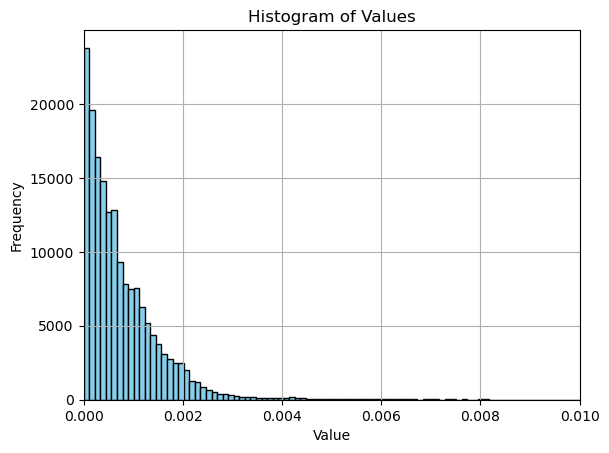

In [43]:


# Plot histogram
plt.hist(all_values[5:], bins=10000, color='skyblue', edgecolor='black')
plt.xlabel('Value')
plt.xlim(0, 0.01)
plt.ylabel('Frequency')
plt.title('Histogram of Values')
plt.grid(True)
plt.show()


### Lets do the same with from_dict instead of from_vec

In [148]:
cd_dict = {}
for dataset in [train, val, test]:
    for i, data in enumerate(dataset):
        print(f"{i}/{len(dataset)}", end='\r')
        gt_pc_path = dataset.get_pc_path(i)
        data_id = data['id']
        
        json_path = gt_pc_path.replace("pc_cad", "cad_json")
        json_path = json_path.replace("ply", "json")

        with open(json_path, "r") as fp:
            data = json.load(fp)

        try:
            cad_seq = CADSequence.from_dict(data)
            cad_seq.normalize()
            shape = create_CAD(cad_seq)
        except Exception as e:
            cd_dict[data_id] = -1 # CADSequence.from_dict error
            continue

        try:
            out_pc = CADsolid2pc(shape, 2000, data_id)
        except Exception as e:
            cd_dict[data_id] = -2 #'CADsolid2pc' error
            continue
        
        if np.max(np.abs(out_pc)) > 2: 
            out_pc = normalize_pc(out_pc)
        
        gt_pc = read_ply(gt_pc_path)
        sample_idx = random.sample(list(range(gt_pc.shape[0])), 2000)
        gt_pc = gt_pc[sample_idx]
    
        cd = chamfer_dist(gt_pc, out_pc)
        cd_dict[data_id] = cd
            
        
    print("Finished")

Finished60982
Finished8
Finished8


In [197]:
print(len(cd_dict))

177948


In [198]:
all_values = df['value'].values.flatten().tolist()

In [199]:
np.max(all_values)

56.92804843655191

In [149]:
df = pd.DataFrame(list(cd_dict.items()), columns=['file_id', 'value'])

In [150]:
df.to_csv('../data/cd_all_samples_from_dict.csv', index=False)

In [151]:
len(df)

177948

In [152]:
vec2CADsolid_fail = df[df['value'] == -1]['file_id'].tolist()
CADsolid2pc_fail = df[df['value'] == -2]['file_id'].tolist()

In [153]:
print(len(vec2CADsolid_fail), len(CADsolid2pc_fail))

0 0


AHA! From dict has no errors, as I already filtered all of the errors back when I first created the dataset.

In [154]:
df_sorted_dict = df.sort_values(by='value', ascending=False)

In [155]:
df_sorted_dict

,file_id,value
92612,00635152,5.692805e+01
103388,00654998,2.225273e+01
150919,00969151,2.634247e+00
513,00818196,2.484779e+00
169519,00629901,1.080896e+00
...,...,...
37424,00316692,2.416207e-10
122118,00197678,1.163318e-10
22474,00440640,5.899103e-11
96491,00153937,4.843940e-11


In [16]:
sample = train[92612]

In [21]:
pcd = o3d.io.read_point_cloud("../models/DeepCAD/dataset/test.ply")

# Convert points to NumPy array
points = np.asarray(pcd.points)

In [22]:
print(points.shape)

(8096, 3)


In [29]:
cd_dict = {}


gt_pc_path = dataset.get_pc_path(92612)
print(gt_pc_path)
data_id = sample['id']

json_path = gt_pc_path.replace("pc_cad", "cad_json")
json_path = json_path.replace("ply", "json")
print(json_path)

with open(json_path, "r") as fp:
    data = json.load(fp)


cad_seq = CADSequence.from_dict(data)
cad_seq.normalize()
print(cad_seq)
shape = create_CAD(cad_seq)


out_pc = CADsolid2pc(shape, 8096, data_id)
print(out_pc.shape)


if np.max(np.abs(out_pc)) > 2: 
    out_pc = normalize_pc(out_pc)

gt_pc = read_ply(gt_pc_path)
sample_idx = random.sample(list(range(gt_pc.shape[0])), 2000)
gt_pc = gt_pc[sample_idx]

cd = chamfer_dist(gt_pc, points)
cd_dict[data_id] = cd
            
        


../data/pc_cad/0063/00635152.ply
../data/cad_json/0063/00635152.json
(0)Sketch-Extrude pair:
  -origin: [0. 0. 0.], normal: [0. 0. 1.], x_axis: [1. 0. 0.], y_axis: [0. 1. 0.]
  -sketch position: [-5.9433  5.9433  0.    ], sketch size: 11.8867
  -operation:0, type:1, extent_one:0.14858318361551934, extent_two:0.0
  -Profile:Loop:
      -Circle: center([175.5 128. ]), radius(47.5)
    -Loop:
      -Circle: center([175.5 128. ]), radius(47.405)
(8096, 3)


In [30]:
print(cd)

65.26599898959238


In [209]:
print(gt_pc.shape)
print(out_pc.shape)

(2000, 3)
(2000, 3)


In [19]:
import open3d as o3d

In [213]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(out_pc)
o3d.io.write_point_cloud("out_pc.ply", pcd)

True

In [257]:
pc_path = dataset.get_pc_path(103388)
json_path = pc_path.replace("pc_cad", "cad_json")
json_path = json_path.replace("ply", "json")
print("pc: ", pc_path)
print("json: ", json_path)

temp_dir = "../data/temporary"
if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)
os.makedirs(temp_dir)
dest_path_pc = os.path.join(temp_dir, os.path.basename(pc_path))
dest_path_json = os.path.join(temp_dir, os.path.basename(json_path))
shutil.copy(pc_path, dest_path_pc)
shutil.copy(json_path, dest_path_json)
print(f"Copied {pc_path} to {dest_path_pc}")
print(f"Copied {json_path} to {dest_path_json}")

save_path = os.path.join(*dest_path_json.split("/")[:-1], os.path.splitext(os.path.basename(dest_path_json))[0] + '.step')
print(save_path)

with open(json_path, "r") as fp:
    data = json.load(fp)

cad_seq = CADSequence.from_dict(data)
cad_seq.normalize()
print(cad_seq)
shape = create_CAD(cad_seq)
out_pc = CADsolid2pc(shape, 2000, data_id)
o3d.io.write_point_cloud("../data/temporary/out_pc.ply", pcd)

write_step_file(shape, save_path)
step_path = save_path
save_path = os.path.join(*step_path.split("/")[:-1], os.path.splitext(os.path.basename(step_path))[0] + '.stl')
step_reader = STEPControl_Reader()
step_reader.ReadFile(step_path)
step_reader.TransferRoots()
shape = step_reader.OneShape()

BRepMesh_IncrementalMesh(shape, 0.1)

stl_writer = StlAPI_Writer()
stl_writer.Write(shape, save_path)
print(f"Wrote stl file to {save_path}")

pc:  ../data/pc_cad/0065/00654998.ply
json:  ../data/cad_json/0065/00654998.json
Copied ../data/pc_cad/0065/00654998.ply to ../data/temporary/00654998.ply
Copied ../data/cad_json/0065/00654998.json to ../data/temporary/00654998.json
../data/temporary/00654998.step
(0)Sketch-Extrude pair:
  -origin: [0. 0. 0.], normal: [0. 0. 1.], x_axis: [1. 0. 0.], y_axis: [0. 1. 0.]
  -sketch position: [-0.6376  0.      0.    ], sketch size: 1.2753
  -operation:0, type:0, extent_one:0.75, extent_two:0.0
  -Profile:Loop:
      -Circle: center([175.5 128. ]), radius(47.50000000000001)
(1)Sketch-Extrude pair:
  -origin: [0. 0. 0.], normal: [1. 0. 0.], x_axis: [ 0.  1. -0.], y_axis: [0. 0. 1.]
  -sketch position: [ 0.      4.1447 -3.1646], sketch size: 3.3158
  -operation:0, type:0, extent_one:0.75, extent_two:0.0
  -Profile:Loop:
      -Line: start([128. 128.]), end([223. 128.])
      -Line: start([223. 128.]), end([223.         208.22198175])
      -Line: start([223.         208.22198175]), end([128.  

In [ ]:
def export2step(json_path):

    save_path = os.path.join(*json_path.split("/")[:-1], os.path.splitext(os.path.basename(json_path))[0] + '.step')

    with open(json_path, "r") as fp:
        data = json.load(fp)

    cad_seq = CADSequence.from_dict(data)
    cad_seq.normalize()
    shape = create_CAD(cad_seq)

    write_step_file(shape, save_path)
    return save_path

def step2stl(step_path):

    save_path = os.path.join(*step_path.split("/")[:-1], os.path.splitext(os.path.basename(step_path))[0] + '.stl')
    step_reader = STEPControl_Reader()
    step_reader.ReadFile(step_path)
    step_reader.TransferRoots()
    shape = step_reader.OneShape()

    BRepMesh_IncrementalMesh(shape, 0.1)

    stl_writer = StlAPI_Writer()
    stl_writer.Write(shape, save_path)
    print(f"Wrote stl file to {save_path}")

def visualize_gt(dataset, idx):
    dest_path_h5 = copy_to_temp(dataset, index)
  #  change_keys(dest_path_h5)
    step_path = export2step(dest_path_h5)
    step2stl(step_path)

In [1]:
a = [1,2,3,4,5,6]
a[:3]

[1, 2, 3]